In [ ]:
import os
import numpy as np

filter_folder = r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Data\starburst_filters"

filter_files = [
    os.path.join(filter_folder, f)
    for f in os.listdir(filter_folder)
    if f.endswith(".txt")
]

filter_files.sort()

print(filter_files)


['D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_ACS_WFC_F435W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_ACS_WFC_F606W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_ACS_WFC_F814W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_WFC3_IR_F105W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_WFC3_IR_F125W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star For

In [12]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

ages_myr_1 = np.arange(0,110,10)
ages_myr_2 = np.arange(200, 1100, 100)

ages_gyr = np.concatenate([ages_myr_1, ages_myr_2]) / 1000

In [13]:
dust = {}
dust["type"] = "Calzetti"
dust["Av"] = 0.2
dust["eta"] = 2. #multiplies Av - extra dust for young stars

nebular = {}   #nebular emission component
nebular["logU"] = -3.   #log_10(ionization parameter)

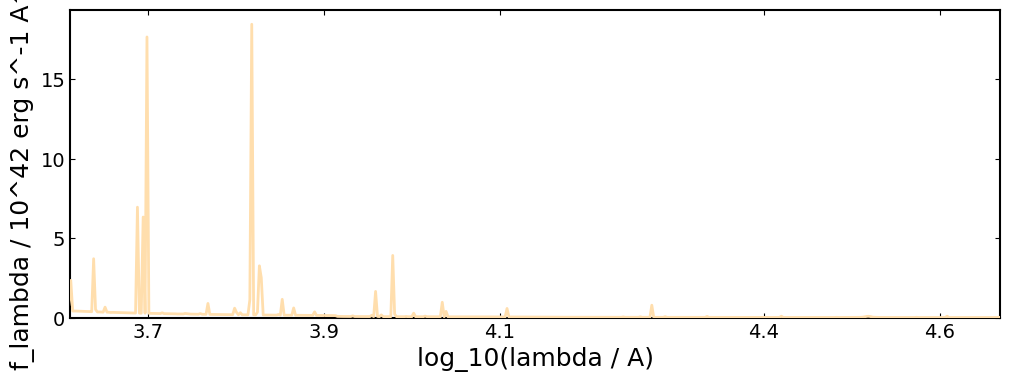

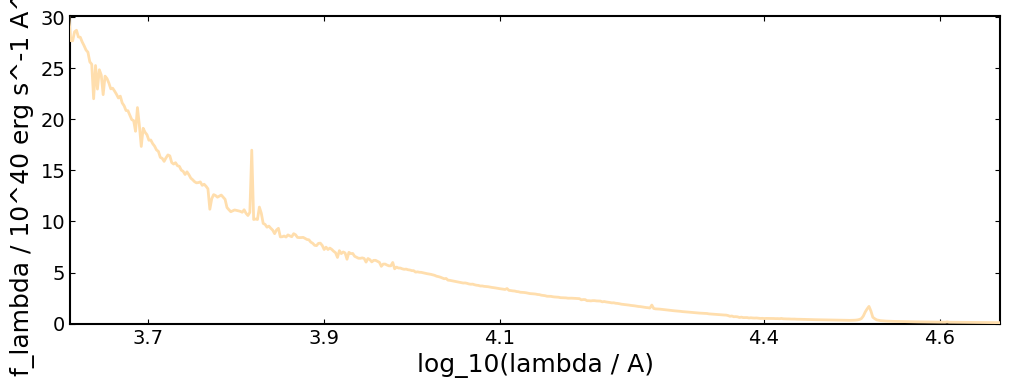

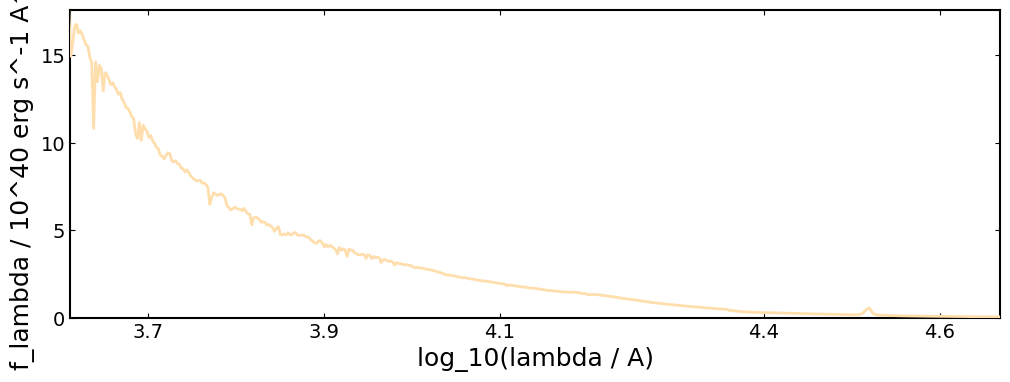

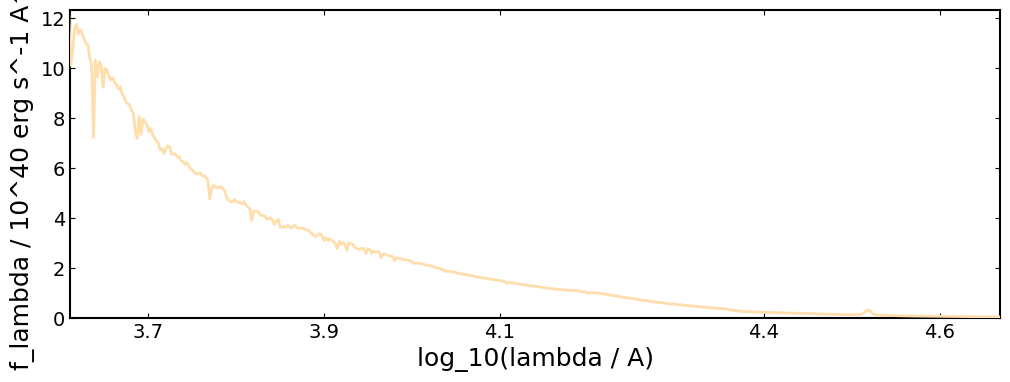

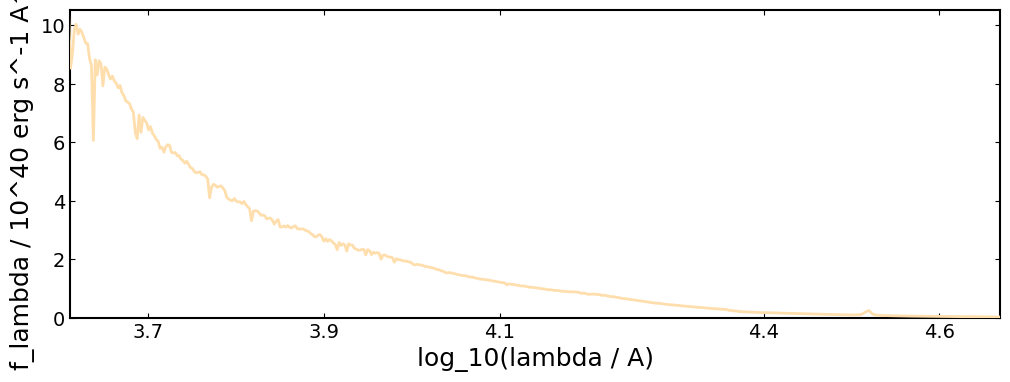

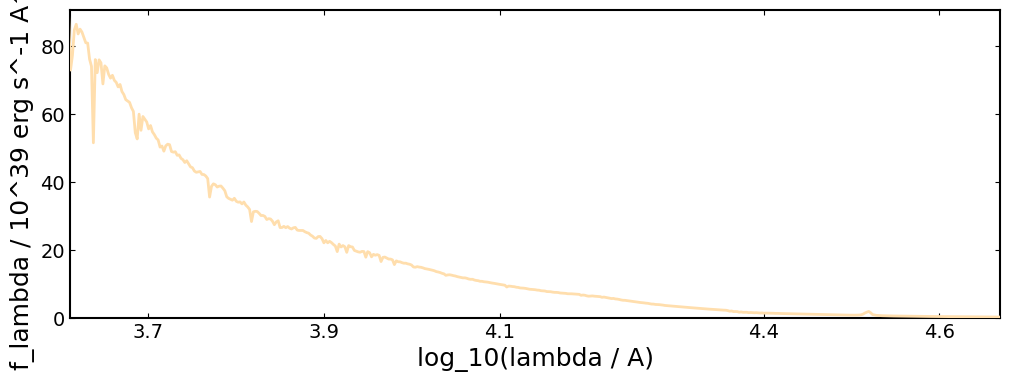

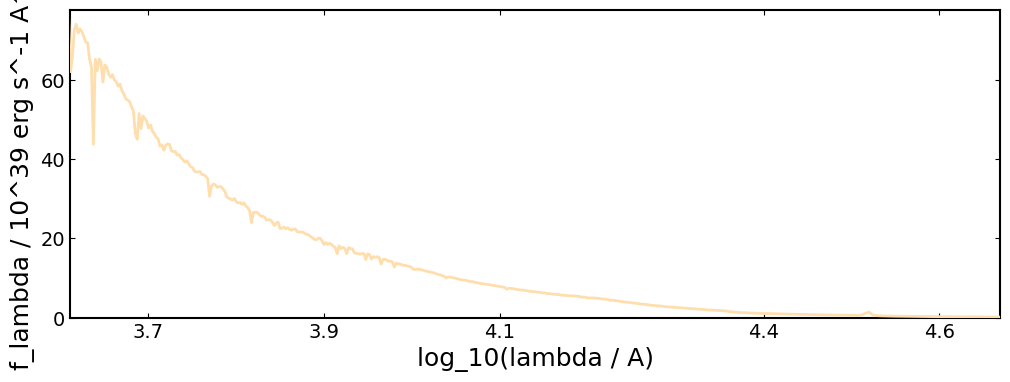

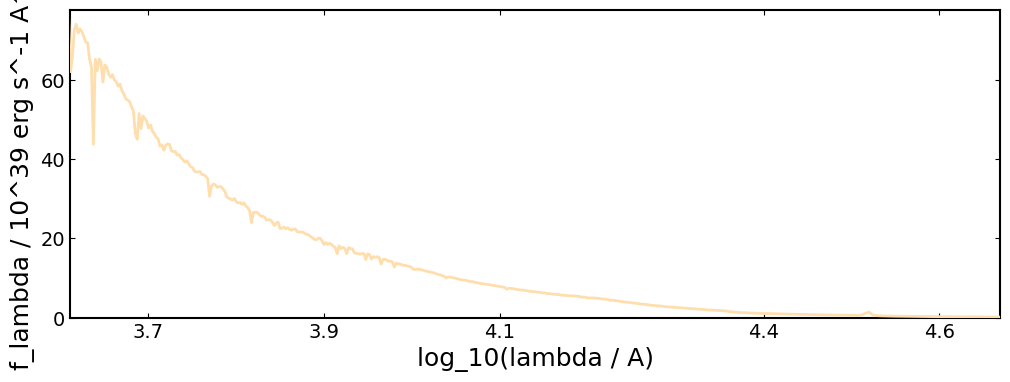

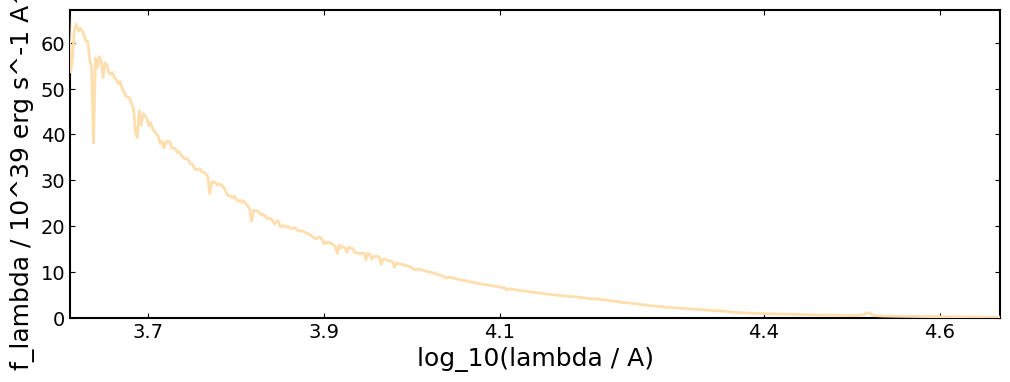

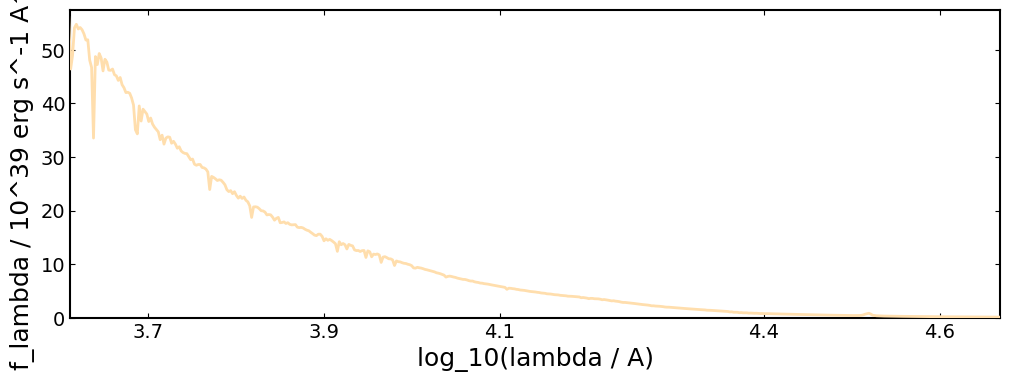

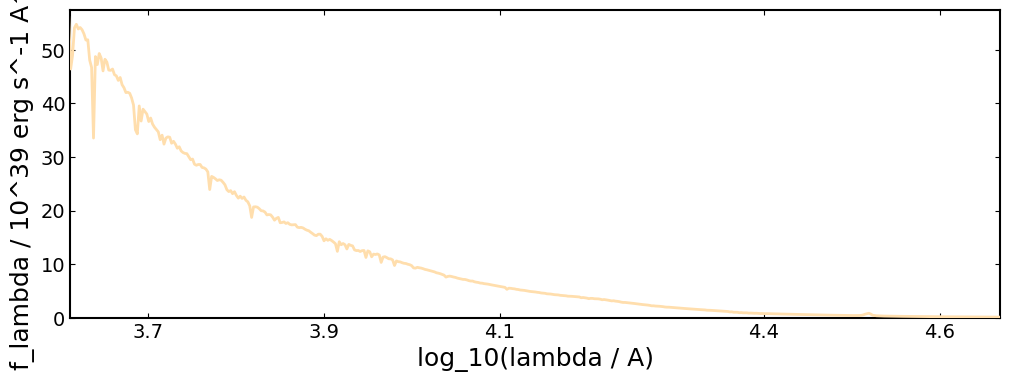

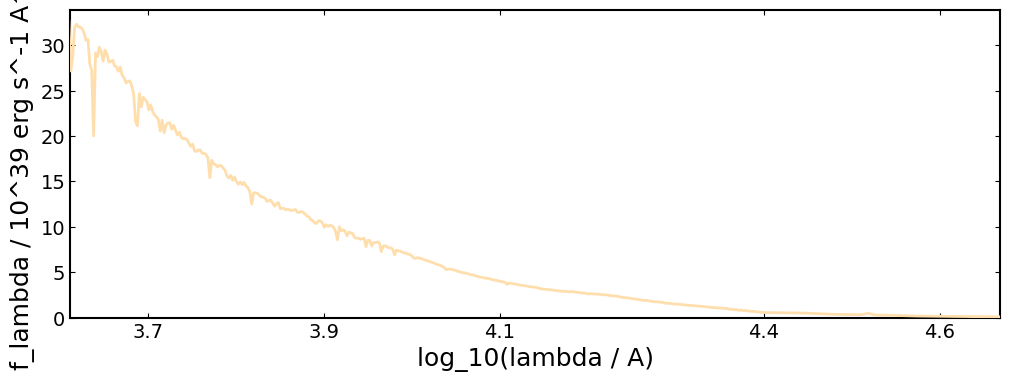

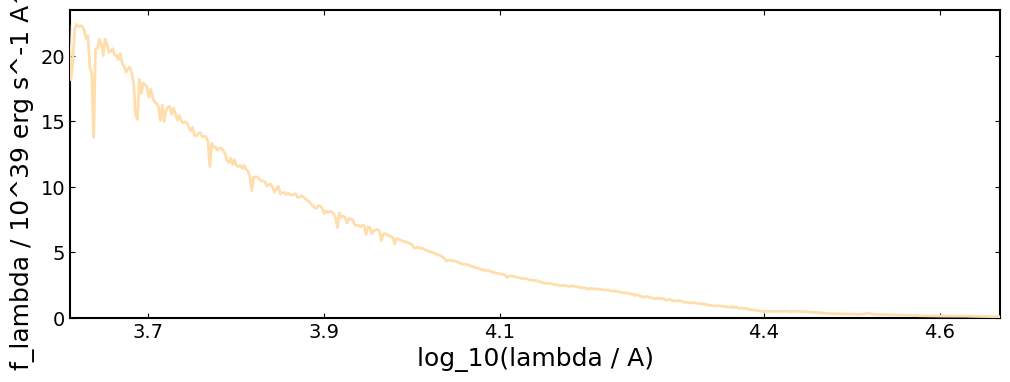

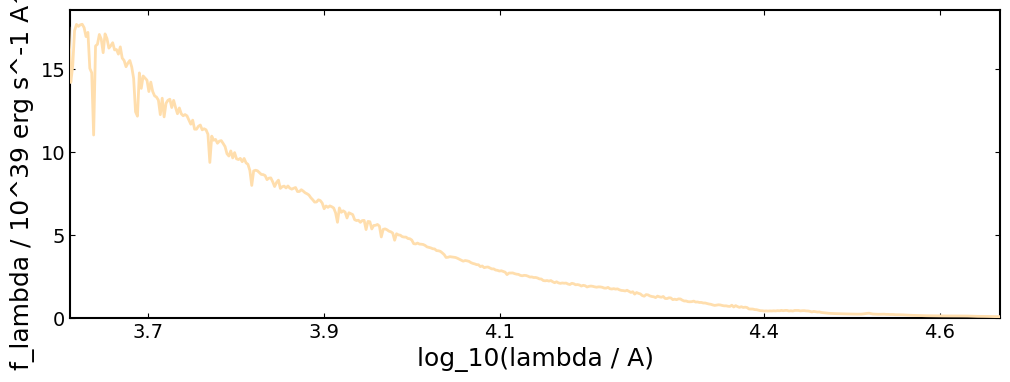

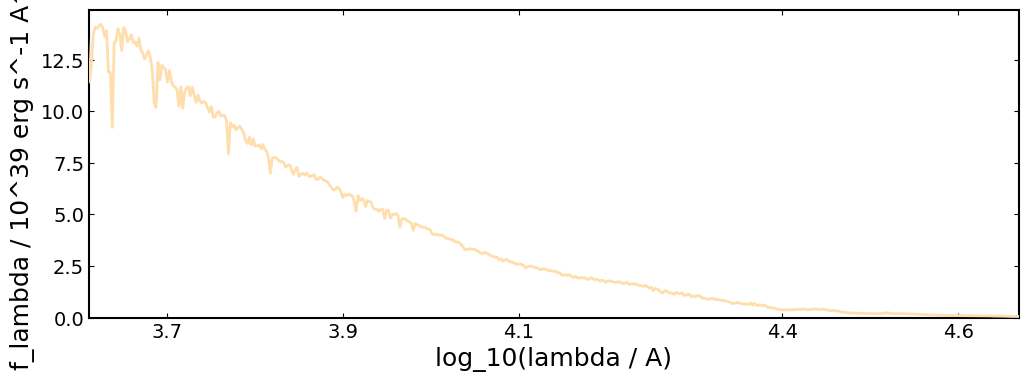

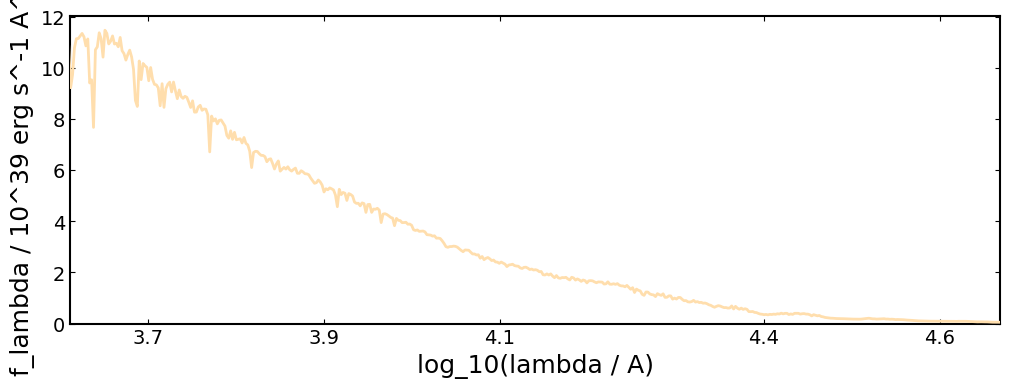

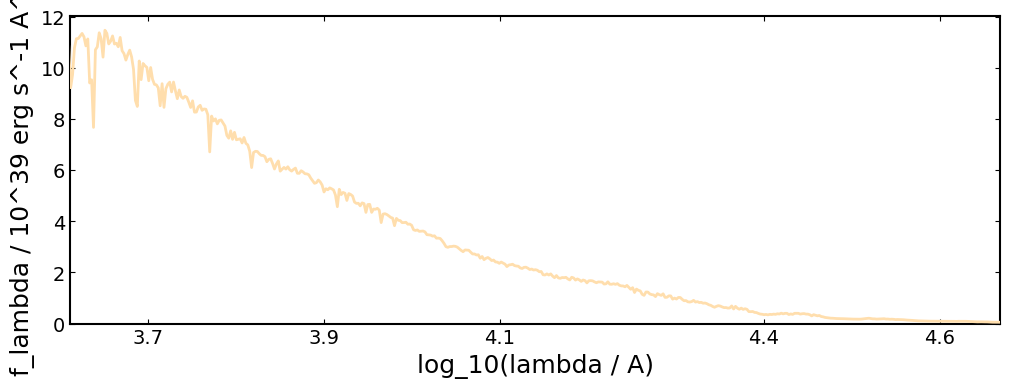

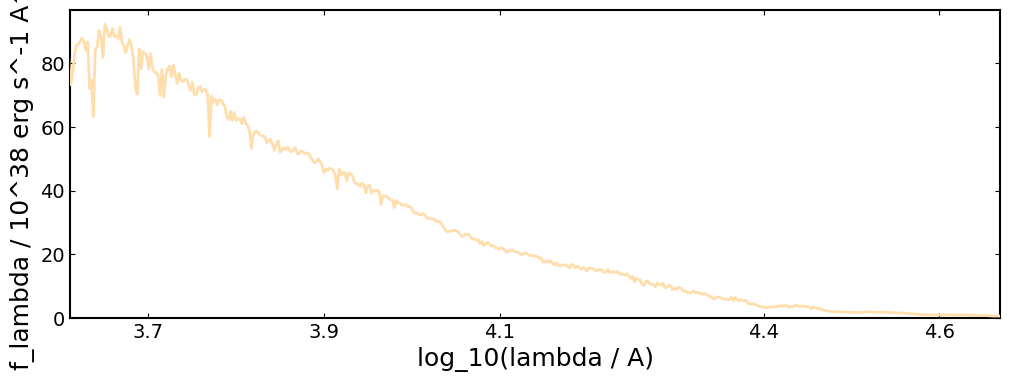

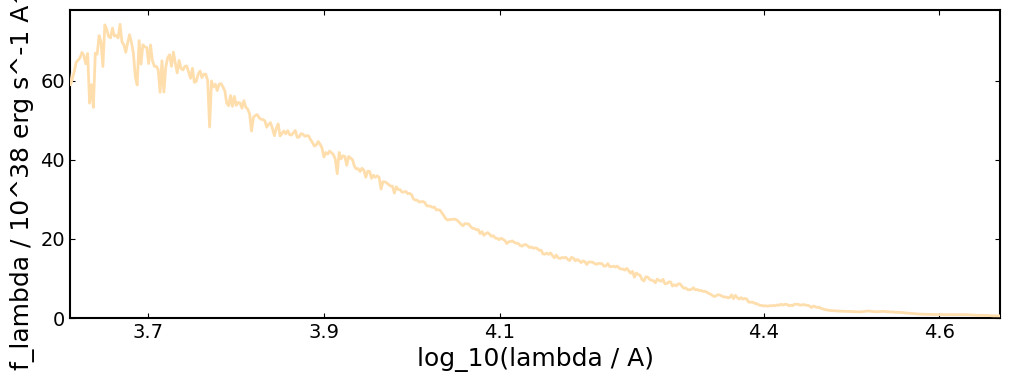

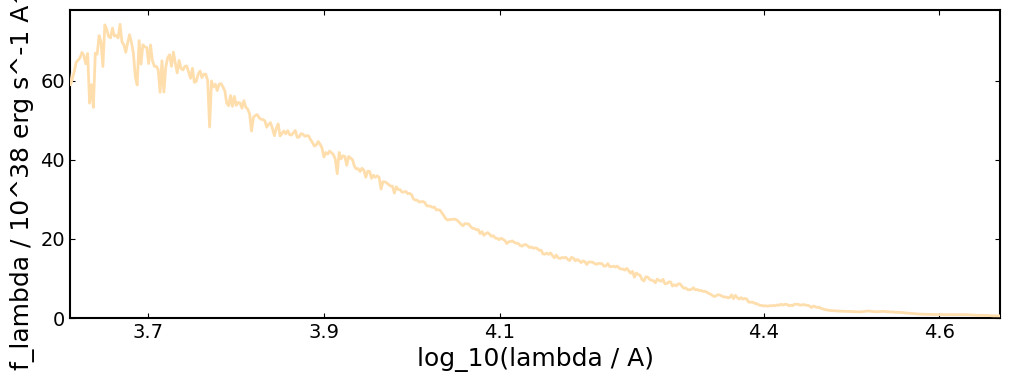

In [14]:
for age in ages_gyr:

    burst = {
        "age": age,           #Gyr before observation
        "massformed": 10,     #log10(M*/Msun)
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "veldisp": 200.,      #km/s
        "t_bc": 0.01       #lifetime of birth clouds (Gyr)
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files, spec_units='mujy', phot_units='mujy'
    )

    #plot spectrum
    fig = model.plot()

    plt.show()


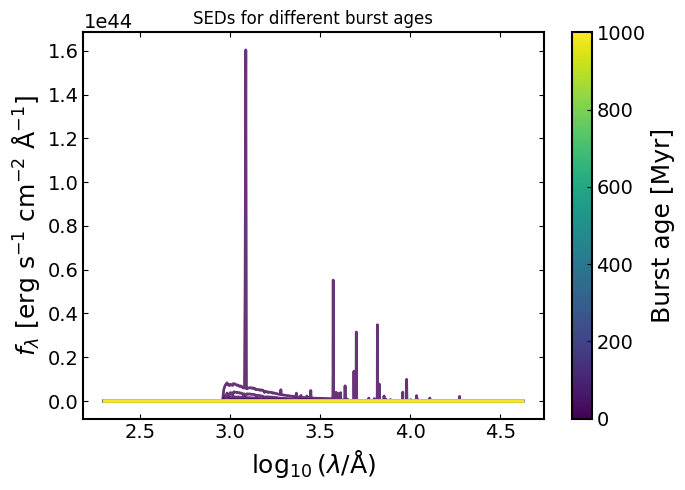

In [17]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

years = np.concatenate([
    np.arange(0, 110, 10),
    np.arange(100, 1100, 100)
])

fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

for t in years:
    
    burst = {
        "age": t / 1000.,     # convert Myr → Gyr
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }
    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs=np.arange(200., 42000., 10.)
    )

    ax.plot(
        np.log10(model.spec_wavs),  # log10(lambda / Å)
        model.spectrum,             # f_lambda [erg s^-1 cm^-2 Å^-1]
        color=cmap(norm(t)),
        alpha=0.8
    )

ax.set_xlabel(r"$\log_{10}(\lambda / \mathrm{\AA})$")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
ax.set_title("SEDs for different burst ages")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()